In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/kaggle/input/datasets/tarunraii/heatwave-dataset-uttar-pradesh-1984-2025/LSTM_ready_input_features_only.csv')

df.head()

,city,date,lat,lon,sin_doy,cos_doy,T2M_RANGE_lag1,skin_air_delta_lag1,T2M_MAX_lag1,T2M_MAX_lag3,...,SOIL_DRYNESS_lag2,SOIL_DRYNESS_lag3,HEAT_STRESS_lag1,QV2M_lag1,PRECTOTCORR_lag1,GWETROOT_lag1,EVLAND_lag1,WS10M_lag1,PS_lag1,T2M_MAX
0,Agra,1984-01-08,27.18,78.01,0.137279,0.990532,16.1220,-0.8792,21.7716,22.6212,...,11.313654,11.175805,8.947605,3.6796,0.0000,0.3728,0.5908,2.1460,99.8248,22.2184
1,Agra,1984-01-09,27.18,78.01,0.154309,0.988023,17.3924,-0.4344,22.2184,22.9300,...,10.762507,11.313654,8.751561,3.4104,0.0000,0.3728,0.6336,2.3592,99.9748,21.9872
2,Agra,1984-01-10,27.18,78.01,0.171293,0.985220,17.0200,-0.4452,21.9872,21.7716,...,10.991034,10.762507,8.726984,3.6084,0.0000,0.3704,0.5776,2.2720,99.8312,22.2992
3,Agra,1984-01-11,27.18,78.01,0.188227,0.982126,15.2428,-0.4044,22.2992,22.2184,...,10.874526,10.991034,9.086300,4.2020,0.0072,0.3692,0.5816,1.8904,99.7580,24.9800
4,Agra,1984-01-12,27.18,78.01,0.205104,0.978740,17.6108,-0.5528,24.9800,21.9872,...,11.025918,10.874526,10.066340,4.2296,0.3556,0.3692,0.6800,2.0252,99.8008,17.4852


In [3]:
# Basic dataset inspection

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(1916625, 30)

Column Names:
Index(['city', 'date', 'lat', 'lon', 'sin_doy', 'cos_doy', 'T2M_RANGE_lag1',
       'skin_air_delta_lag1', 'T2M_MAX_lag1', 'T2M_MAX_lag3', 'T2M_MAX_lag7',
       'T2M_MAX_roll7_mean', 'T2M_MAX_roll7_std', 'ALLSKY_lag1', 'CLRSKY_lag1',
       'RADIATION_EFFECTIVE_lag1', 'CLOUD_AMT_lag1', 'ATM_DRYNESS_lag1',
       'ATM_DRYNESS_lag2', 'SOIL_DRYNESS_lag1', 'SOIL_DRYNESS_lag2',
       'SOIL_DRYNESS_lag3', 'HEAT_STRESS_lag1', 'QV2M_lag1',
       'PRECTOTCORR_lag1', 'GWETROOT_lag1', 'EVLAND_lag1', 'WS10M_lag1',
       'PS_lag1', 'T2M_MAX'],
      dtype='object')

Data Types:
city                         object
date                         object
lat                         float64
lon                         float64
sin_doy                     float64
cos_doy                     float64
T2M_RANGE_lag1              float64
skin_air_delta_lag1         float64
T2M_MAX_lag1                float64
T2M_MAX_lag3                float64
T2M_MAX_lag7        

# **Exploratory Data Analysis**
---

In [4]:
#convert date column to datetime dtype
df['date'] = pd.to_datetime(df['date'])

print("\nDate Range:")
print(df['date'].min(), "to", df['date'].max())


Date Range:
1984-01-08 00:00:00 to 2025-12-30 00:00:00


In [5]:
print("Number of districts:", df['city'].nunique())
print(df['city'].unique()[:20])

Number of districts: 125
['Agra' 'Aligarh' 'Ambedkar_Nagar' 'Amethi' 'Amroha' 'Ashoknagar'
 'Auraiya' 'Ayodhya' 'Azamgarh' 'Baghpat' 'Bahraich' 'Ballia' 'Balrampur'
 'Balrampur_CG' 'Banda' 'Banke_Nepal' 'Barabanki' 'Bardiya_Nepal'
 'Bareilly' 'Basti']


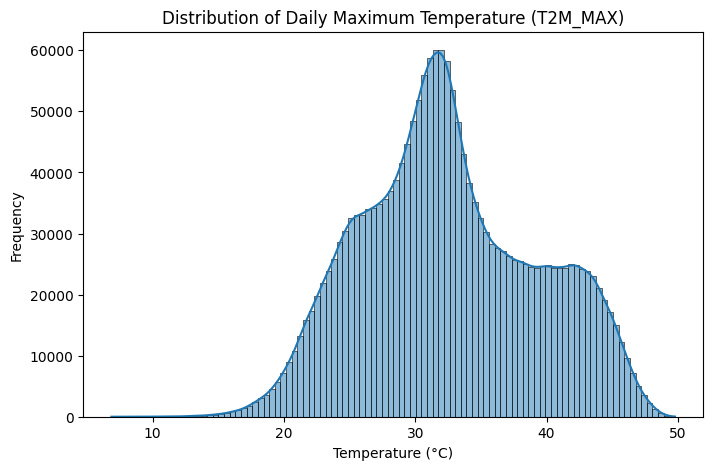

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['T2M_MAX'], bins=100, kde=True)

plt.title("Distribution of Daily Maximum Temperature (T2M_MAX)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

### Distribution of Daily Maximum Temperature (T2M_MAX)

The distribution of daily maximum temperature shows that most temperature values lie between **25°C and 35°C**, with the peak of the distribution around **30–32°C**. The distribution is slightly **right-skewed**, indicating the presence of higher temperature extremes extending toward **45–50°C**.

These extreme values represent potential **heatwave conditions**, which occur in the upper tail of the distribution. Understanding this distribution helps identify the range in which normal temperatures occur and where extreme heat events begin to appear in the dataset.

## **Which months are hottest?**
---

In [7]:
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

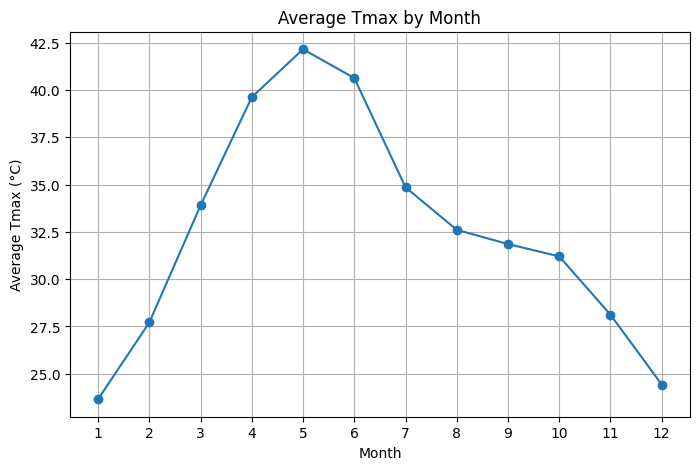

In [8]:
# monthly average temperature
monthly_temp = df.groupby('month')['T2M_MAX'].mean()

plt.figure(figsize=(8,5))
monthly_temp.plot(marker='o')

plt.title("Average Tmax by Month")
plt.xlabel("Month")
plt.ylabel("Average Tmax (°C)")

plt.xticks(range(1,13))
plt.grid(True)

plt.show()

### Seasonal Pattern of Maximum Temperature

The monthly average Tmax shows a clear **seasonal temperature cycle**. Temperatures gradually rise from **January (~24°C)** through spring and reach their peak in **May (~42°C)**, indicating the peak heat season in North India.

After May–June, temperatures begin to decline with the onset of the **monsoon season**, dropping sharply in **July (~35°C)** and continuing to decrease through **August and September**. Cooler temperatures persist from **October to February**.

This seasonal pattern confirms that **April–June is the primary heatwave period**, which is consistent with the climatology of the Indo-Gangetic plains.

## **Temperature Trend Across Years**
---

In [9]:
yearly_temp = df.groupby('year')['T2M_MAX'].mean()

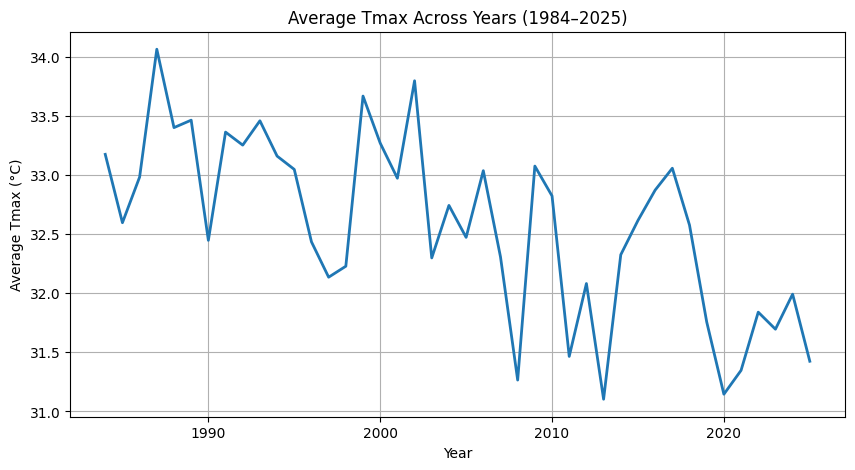

In [10]:
plt.figure(figsize=(10,5))

plt.plot(yearly_temp.index, yearly_temp.values, linewidth=2)

plt.title("Average Tmax Across Years (1984–2025)")
plt.xlabel("Year")
plt.ylabel("Average Tmax (°C)")

plt.grid(True)

plt.show()

### Yearly Trend of Maximum Temperature

The yearly average Tmax between 1984 and 2025 shows noticeable **interannual variability**, with values fluctuating roughly between **31°C and 34°C**. While there are periods of warmer and cooler years, the overall trend does not show a strong monotonic increase when averaged across all districts.

This suggests that regional temperature variability is influenced by large-scale climatic factors such as **monsoon variability and atmospheric circulation patterns**. Although the yearly average temperature does not exhibit a clear warming trend, extreme temperature events in the upper tail of the distribution may still increase over time, which is critical for heatwave analysis.

## **Hottest Districts Analysis**
---

In [11]:
district_temp = df.groupby('city')['T2M_MAX'].mean().sort_values(ascending=False)

In [12]:
# 20 hottest districts
district_temp.head(20)

city
Bharatpur       33.902800
Dholpur         33.866182
Bhind           33.857809
Morena          33.838385
Agra            33.819583
Mathura         33.808102
Jalaun          33.807582
Firozabad       33.784506
Etawah          33.749068
Hamirpur        33.708018
Auraiya         33.691336
Mainpuri        33.624251
Kaushambi       33.599234
Banda           33.596090
Hathras         33.592436
Prayagraj       33.576713
Sheopur         33.574895
Kanpur_Dehat    33.562704
Bhadohi         33.556154
Etah            33.529332
Name: T2M_MAX, dtype: float64

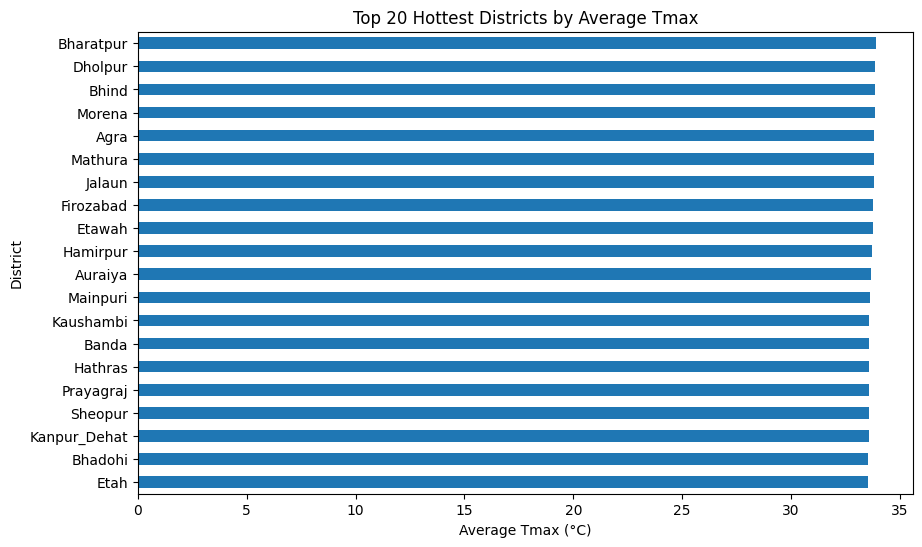

In [13]:
import matplotlib.pyplot as plt

top20 = district_temp.head(20)

plt.figure(figsize=(10,6))
top20.sort_values().plot(kind='barh')

plt.title("Top 20 Hottest Districts by Average Tmax")
plt.xlabel("Average Tmax (°C)")
plt.ylabel("District")

plt.show()

### Spatial Distribution of Hottest Districts

The top 20 districts with the highest average Tmax are primarily located in the **Rajasthan border region, Chambal basin, western Uttar Pradesh, and the Bundelkhand region**. Districts such as Bharatpur, Dholpur, Bhind, Morena, Agra, and Mathura consistently show the highest average maximum temperatures, with values close to **34–35°C**.

These regions are characterized by **semi-arid climate conditions, lower vegetation cover, and higher solar radiation**, which contribute to consistently higher daytime temperatures. The presence of several Rajasthan and Madhya Pradesh border districts among the hottest regions highlights the strong **regional climatic influence across administrative boundaries**.

This spatial pattern is important for heatwave prediction because extreme heat often propagates geographically from **western and southwestern regions toward central Uttar Pradesh**.

## Temperature Distribution During Heatwave Season (Apr–Jun)
---

In [14]:
heat_season = df[df['month'].isin([4,5,6])]

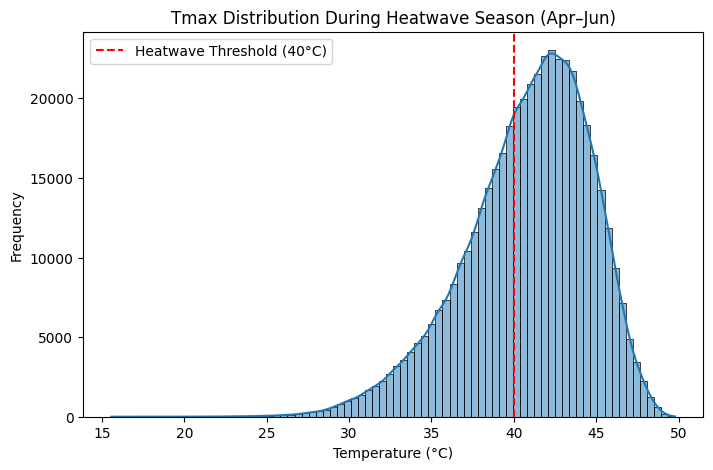

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(heat_season['T2M_MAX'], bins=80, kde=True)

plt.axvline(40, color='red', linestyle='--', label='Heatwave Threshold (40°C)')

plt.title("Tmax Distribution During Heatwave Season (Apr–Jun)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.legend()
plt.show()

### Distribution of Tmax During Heatwave Season (April–June)

The distribution of maximum temperature during the heatwave season (April–June) is strongly shifted toward higher temperatures compared to the full-year distribution. Most values lie between **38°C and 45°C**, with the peak of the distribution occurring around **42–43°C**.

The vertical red line at **40°C** represents the **IMD heatwave threshold**. A significant portion of the distribution lies to the right of this threshold, indicating that a large number of days during the pre-monsoon period experience temperatures high enough to qualify as potential heatwave conditions.

The distribution also exhibits a long right tail extending up to **49–50°C**, representing severe heat events. This confirms that the dataset contains sufficient extreme temperature observations for training a model aimed at forecasting heatwaves.

## Temperature Variability Across Districts
---

In [16]:
sample_df = df.sample(50000, random_state=42)

In [17]:
# choosing the top 20 hottest districts from the previous step
top_districts = district_temp.head(20).index
sample_df = sample_df[sample_df['city'].isin(top_districts)]

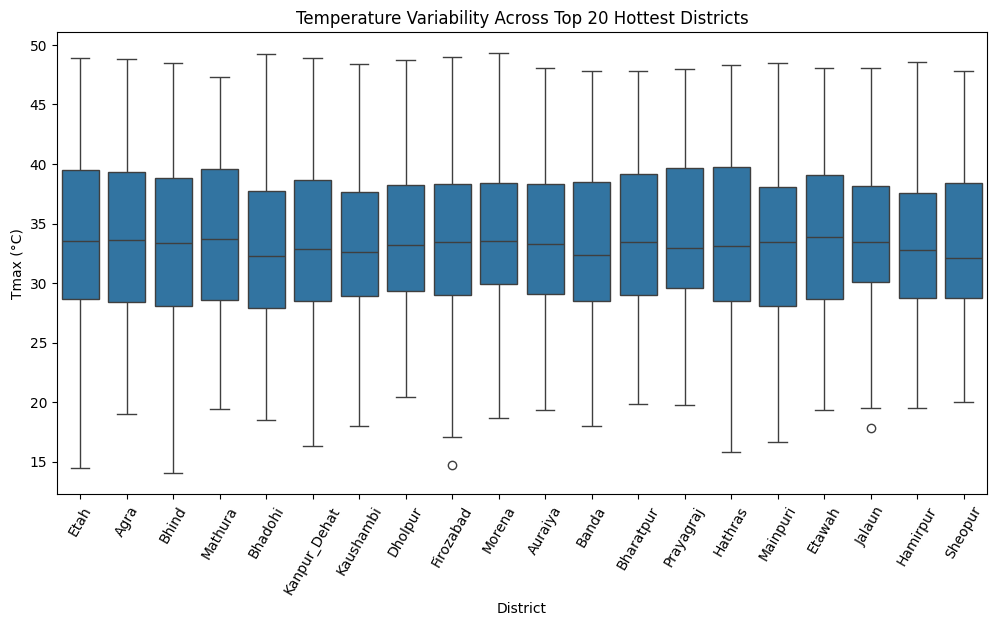

In [18]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=sample_df,
    x='city',
    y='T2M_MAX'
)

plt.xticks(rotation=60)
plt.title("Temperature Variability Across Top 20 Hottest Districts")
plt.xlabel("District")
plt.ylabel("Tmax (°C)")

plt.show()

## Correlation Analysis
---

In [19]:
# selecting numeric features
numeric_df = df.select_dtypes(include=['float64', 'int64'])

In [20]:
corr_matrix = numeric_df.corr()

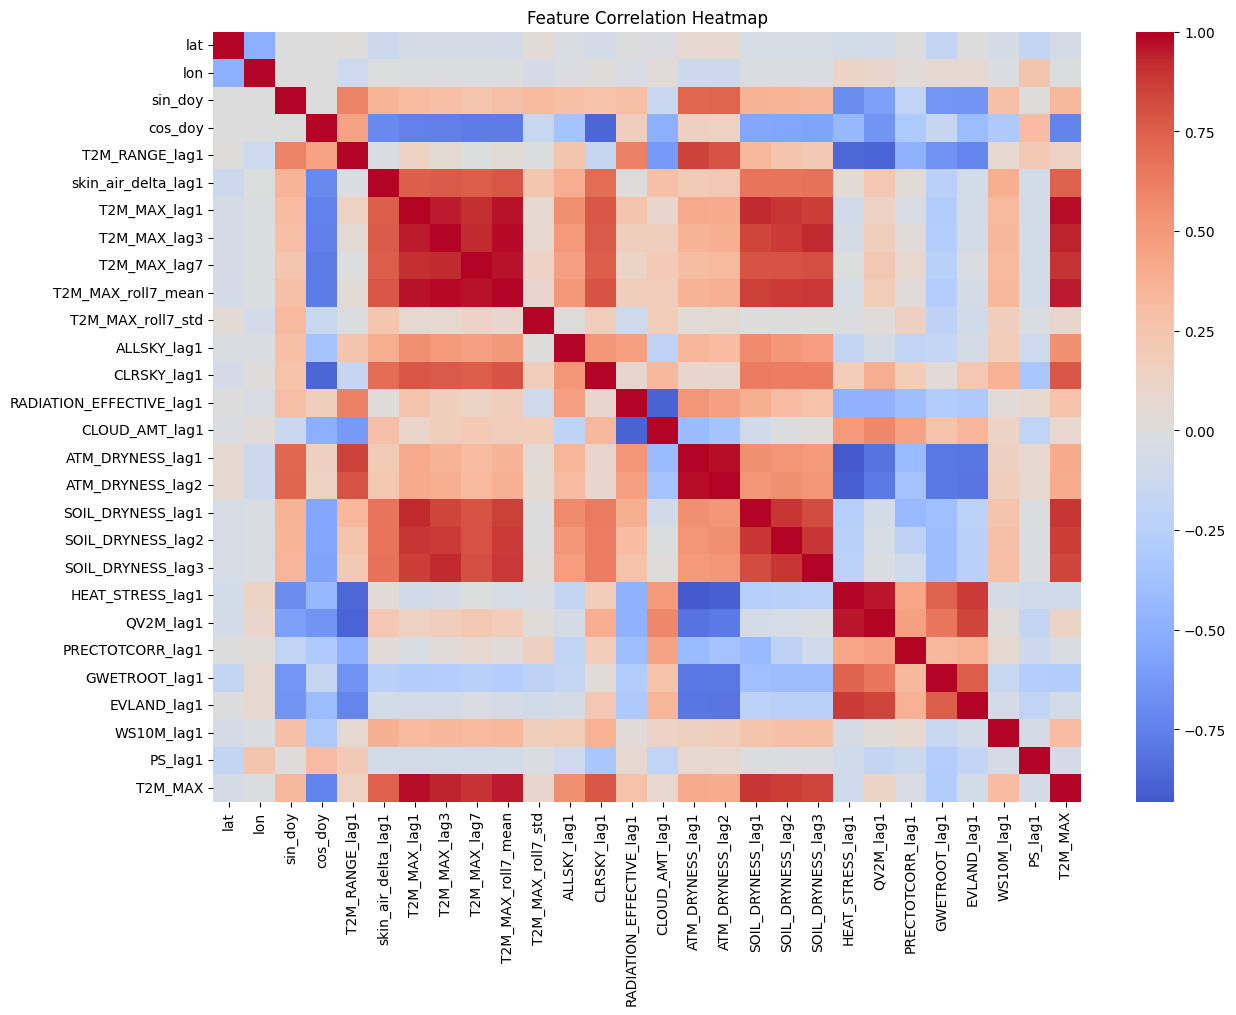

In [21]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

### Feature Correlation Analysis

The correlation heatmap reveals several strong relationships between the target variable (T2M_MAX) and lagged temperature features. Variables such as **T2M_MAX_lag1, T2M_MAX_lag3, T2M_MAX_lag7, and T2M_MAX_roll7_mean** exhibit very high positive correlations with the target, reflecting the strong temporal persistence of temperature.

Several groups of features also show strong intercorrelations, indicating potential multicollinearity. These include the **soil dryness variables (SOIL_DRYNESS_lag1–3)**, **atmospheric dryness variables (ATM_DRYNESS_lag1–2)**, and **radiation-related variables (ALLSKY_lag1, CLRSKY_lag1, RADIATION_EFFECTIVE_lag1)**.

While some variables such as **latitude, longitude, and surface pressure** display relatively weak direct correlations with Tmax, they may still provide useful contextual or spatial information for predictive models. These insights will guide the feature selection process in the next stage of the analysis.

## Variance Inflation Factor
---

Variance Inflation Factor measures how much a feature is explained by other features

In [22]:
# !pip install statsmodels

In [23]:
# from statsmodels.stats.outliers_influence import variance_inflation_factor

In [24]:
# exclude target, city and date column
features = df.drop(columns=['city','date','T2M_MAX'])

In [25]:
# # Convert once (important)
# X = features.values
# n_features = X.shape[1]

# vif_values = np.zeros(n_features)

# # Compute VIF efficiently
# for i in range(n_features):
#     vif_values[i] = variance_inflation_factor(X, i)

# # Create dataframe
# vif_data = pd.DataFrame({
#     "feature": features.columns,
#     "VIF": vif_values
# }).sort_values(by="VIF", ascending=False)

# vif_data

### Feature Selection using VIF

Variance Inflation Factor (VIF) analysis was used to identify multicollinearity among the predictor variables. Extremely high VIF values were observed for several groups of features, particularly lagged variables derived from similar physical processes.

Rather than removing all high-VIF variables, domain knowledge was applied to retain important predictors such as lagged temperature variables (T2M_MAX_lag1, T2M_MAX_lag3, T2M_MAX_lag7), which are essential for autoregressive forecasting. Redundant features within strongly correlated groups were reduced by keeping only the most informative variables.

Specifically, additional lagged soil dryness variables, atmospheric dryness lag2, and redundant radiation variables were removed. Temporal variables such as month and year were also excluded since seasonality is already captured using sine and cosine day-of-year encodings.

After feature reduction, the dataset retained a compact set of predictors capturing temperature persistence, atmospheric conditions, radiation effects, soil moisture, and spatial information.

In [26]:
drop_cols = [
    'SOIL_DRYNESS_lag2',
    'SOIL_DRYNESS_lag3',
    'ATM_DRYNESS_lag2',
    'ALLSKY_lag1',
    'CLRSKY_lag1',
    'month',
    'year'
]

df_model = df.drop(columns=drop_cols)

print("New dataset shape:", df_model.shape)

New dataset shape: (1916625, 25)


# Data Preparation
---
### Chronological Train–Validation–Test Split

To avoid data leakage in time-series forecasting, the dataset was divided using a chronological split rather than a random split. The training set contains data from **1984–2010**, representing 30 years of historical observations used to learn long-term climate patterns. The validation set spans **2011–2018** and is used for hyperparameter tuning and model selection. The final test set covers **2019–2025**, which includes recent extreme heat events such as the **2022 Uttar Pradesh heatwave**.

This chronological division ensures that the model is always evaluated on future data that was not available during training, preserving the integrity of the forecasting task.

In [27]:
df_model['year'] = df_model['date'].dt.year

train_df = df_model[df_model['year'] <= 2010]

val_df = df_model[(df_model['year'] > 2010) & (df_model['year'] <= 2018)]

test_df = df_model[df_model['year'] > 2018]

In [28]:
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1231875, 26)
Validation shape: (365250, 26)
Test shape: (319500, 26)


In [29]:
print(train_df['date'].min(), train_df['date'].max())
print(val_df['date'].min(), val_df['date'].max())
print(test_df['date'].min(), test_df['date'].max())

1984-01-08 00:00:00 2010-12-31 00:00:00
2011-01-01 00:00:00 2018-12-31 00:00:00
2019-01-01 00:00:00 2025-12-30 00:00:00


# Feature Scaling
---

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
# drop columns which are not used for training

X_train = train_df.drop(columns=['city','date','year','T2M_MAX'])
y_train = train_df['T2M_MAX']

X_val = val_df.drop(columns=['city','date','year','T2M_MAX'])
y_val = val_df['T2M_MAX']

X_test = test_df.drop(columns=['city','date','year','T2M_MAX'])
y_test = test_df['T2M_MAX']

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) # fit only on training data to avoid data leakage
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# When deploying the model later, you must use the same scaler using joblib.

# Multi-Step Sequence Creation (Direct Forecasting)

#### Objective

Prepare the dataset for **direct multi-step forecasting**, where the model predicts the next 10 days of temperature using the past 30 days of data.

---

#### Approach

* **Input (X):** Past 30 days of features
* **Target (y):** Next 10 days of target variable (T2M_MAX)

Each training sample is constructed as:

```
X → [t-30, ..., t-1]  
y → [t, t+1, ..., t+9]
```

---

#### Key Design Choices

* Sequences are created **separately for each city** to preserve temporal consistency
* A **sliding window** approach is used to generate multiple samples
* No mixing of time steps across cities
* No data leakage: future values are strictly excluded from inputs

---

#### Output Shapes

* `X_seq → (samples, 30, features)`
* `y_seq → (samples, 10)`

---

#### Why This Matters

This setup enables the model to:

* Predict all 10 future days **in a single forward pass**
* Avoid recursive predictions
* Eliminate **error propagation** seen in autoregressive models


### 📌 Sequence Creation for Direct Multi-Step Forecasting

#### Objective

Transform the time-series data into supervised learning format for training a model that predicts the next 10 days of temperature using the past 30 days.

---

#### Methodology

For each city, sequences are created using a sliding window approach:

* **Input (X):** Past 30 consecutive days of features
* **Target (y):** Next 10 consecutive days of the target variable (T2M_MAX)

Each sample is constructed as:

```
X → [t-30, ..., t-1]  
y → [t, t+1, ..., t+9]
```

---

#### Key Steps

1. Data is grouped **city-wise** to maintain temporal consistency
2. For each city:

   * A sliding window of size 30 is used to create inputs
   * The following 10 days are used as targets
3. All sequences from different cities are then concatenated

---

#### Important Considerations

* **No Data Leakage:** Future values are not included in inputs
* **City Independence:** Sequences do not cross city boundaries
* **Minimum Length Requirement:** Each city must have at least 40 days of data (30 input + 10 output)

---

#### Output Format

* `X_seq → (samples, 30, features)`
* `y_seq → (samples, 10)`

---

#### Why This Approach?

This sequence structure enables **direct multi-step forecasting**, where the model learns to predict all 10 future days simultaneously, avoiding recursive predictions and eliminating error propagation.


In [33]:
def create_sequences_direct(X, y, cities, window=30, horizon=10):
    X_seq = []
    y_seq = []

    unique_cities = np.unique(cities)

    for city in unique_cities:
        idx = np.where(cities == city)[0]

        X_city = X[idx]
        y_city = y[idx]

        n = len(X_city)

        for i in range(n - window - horizon + 1):
            X_seq.append(X_city[i : i + window])
            y_seq.append(y_city[i + window : i + window + horizon])

    return np.array(X_seq), np.array(y_seq)

In [34]:
cities_train = train_df['city'].values
cities_val   = val_df['city'].values
cities_test  = test_df['city'].values

X_train_seq, y_train_seq = create_sequences_direct(
    X_train_scaled, y_train.values, cities_train
)

X_val_seq, y_val_seq = create_sequences_direct(
    X_val_scaled, y_val.values, cities_val
)

X_test_seq, y_test_seq = create_sequences_direct(
    X_test_scaled, y_test.values, cities_test
)

In [35]:
print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)

print("X_val_seq:", X_val_seq.shape)
print("y_val_seq:", y_val_seq.shape)

print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)

X_train_seq: (1227000, 30, 22)
y_train_seq: (1227000, 10)
X_val_seq: (360375, 30, 22)
y_val_seq: (360375, 10)
X_test_seq: (314625, 30, 22)
y_test_seq: (314625, 10)


In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(10, dtype='float32')   # 10 day output
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

2026-04-20 19:21:58.636486: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776712919.049659      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776712919.158165      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776712920.208982      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776712920.209024      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776712920.209027      23 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,682 (96.41 KB)

 Trainable params: 24,682 (96.41 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')   # to improve speed on T4 GPU

In [38]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15, # instead of 10
    restore_best_weights=True
)

# reduce_lr = ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.5,
#     patience=5,
#     min_lr=1e-6
# )
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,       # was 5, give it more room
    min_lr=1e-6
)

In [39]:
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=128,   # use 64 if memory issue
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30


I0000 00:00:1776712971.295356      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


9586/9586 ━━━━━━━━━━━━━━━━━━━━ 84s 8ms/step - loss: 56.3027 - mae: 3.8957 - val_loss: 4.9210 - val_mae: 1.6365 - learning_rate: 0.0010
Epoch 2/30
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 76s 8ms/step - loss: 4.5414 - mae: 1.6106 - val_loss: 5.2467 - val_mae: 1.7001 - learning_rate: 0.0010
Epoch 3/30
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 75s 8ms/step - loss: 3.7869 - mae: 1.4762 - val_loss: 5.5789 - val_mae: 1.7475 - learning_rate: 0.0010
Epoch 4/30
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 74s 8ms/step - loss: 3.4123 - mae: 1.4018 - val_loss: 5.8815 - val_mae: 1.7951 - learning_rate: 0.0010
Epoch 5/30
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 72s 8ms/step - loss: 3.1645 - mae: 1.3507 - val_loss: 5.8141 - val_mae: 1.7826 - learning_rate: 0.0010
Epoch 6/30
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 71s 7ms/step - loss: 2.9878 - mae: 1.3122 - val_loss: 5.8888 - val_mae: 1.7942 - learning_rate: 0.0010
Epoch 7/30
9586/9586 ━━━━━━━━━━━━━━━━━━━━ 71s 7ms/step - loss: 2.8616 - mae: 1.2837 - val_loss: 5.8907 - val_mae: 1.7997 - learning_rate: 0.

## MAE per Day (Validation Set)
---

In [40]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Predictions
y_val_pred = model.predict(X_val_seq)

# MAE per day
mae_per_day = []

for i in range(10):
    mae = mean_absolute_error(y_val_seq[:, i], y_val_pred[:, i])
    mae_per_day.append(mae)

print("MAE per day:", mae_per_day)

11262/11262 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step
MAE per day: [1.357086570654508, 1.4883167014159053, 1.564304379298112, 1.614140991484641, 1.6571083678183955, 1.6862898908321335, 1.7164145366115924, 1.7411217211401901, 1.7568421913776104, 1.7831113654049093]


## Test Set Evaluation
---

In [41]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# Predictions
y_test_pred = model.predict(X_test_seq, batch_size=512, verbose=1)

# Compute MAE per day
mae_per_day = []

for day in range(10):
    mae = mean_absolute_error(y_test_seq[:, day], y_test_pred[:, day])
    mae_per_day.append(mae)

print("MAE per day (Test):", mae_per_day)

615/615 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
MAE per day (Test): [1.4134621729228747, 1.541735846957981, 1.6239550622127148, 1.6860324972332772, 1.735720466299039, 1.7713921672700341, 1.810578011279229, 1.8403231546084282, 1.8575802720808945, 1.8893193629771357]


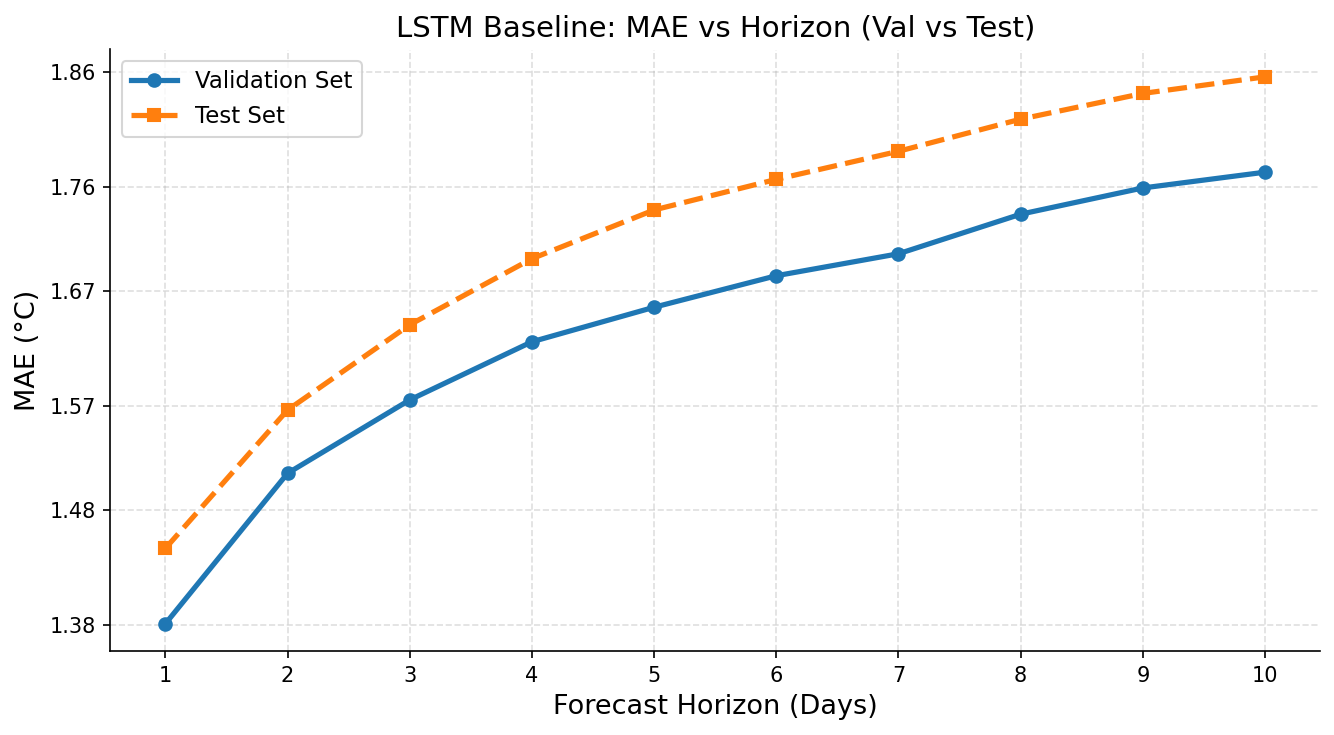

In [42]:
import matplotlib.pyplot as plt
import numpy as np

days = np.arange(1, 11)
mae_val  = [1.38096515607513, 1.5115379354863099, 1.5752242047503857, 1.6256873931284452,
            1.655643132287771, 1.682972986576483, 1.702044723363225, 1.736382360131328,
            1.759146996718574, 1.7728454025354212]
mae_test = [1.446380859761066, 1.5664284157729593, 1.6404207193683245, 1.697780266627315,
            1.7400617549255784, 1.766601923210052, 1.790975574127001, 1.8188709585616731,
            1.8411779733069817, 1.8555760675467559]

plt.figure(figsize=(9, 5), dpi=150)

plt.plot(days, mae_val,  marker='o', linewidth=2.5, markersize=6, label='Validation Set')
plt.plot(days, mae_test, marker='s', linewidth=2.5, markersize=6, label='Test Set', linestyle='--')

plt.xlabel("Forecast Horizon (Days)", fontsize=13)
plt.ylabel("MAE (°C)", fontsize=13)
plt.title("LSTM Baseline: MAE vs Horizon (Val vs Test)", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(days)

all_vals = mae_val + mae_test
plt.yticks(np.round(np.linspace(min(all_vals), max(all_vals), 6), 2))

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [43]:
model.save('lstm_baseline_final.keras')

In [44]:
from tensorflow.keras.models import load_model
import numpy as np

# Load the saved LSTM model
lstm_model = load_model('/kaggle/working/lstm_baseline_final.keras')
print("Model loaded successfully")

# Generate predictions on validation set
print("Generating validation predictions...")
y_lstm_val = lstm_model.predict(X_val_seq, batch_size=512, verbose=1)

# Generate predictions on test set
print("Generating test predictions...")
y_lstm_test = lstm_model.predict(X_test_seq, batch_size=512, verbose=1)

print(f"y_lstm_val shape : {y_lstm_val.shape}")   # expected (360375, 10)
print(f"y_lstm_test shape: {y_lstm_test.shape}")   # expected (314625, 10)

# Save everything needed for Notebook 2
np.save('/kaggle/working/y_lstm_val.npy',  y_lstm_val)
np.save('/kaggle/working/y_lstm_test.npy', y_lstm_test)
np.save('/kaggle/working/y_val_seq.npy',   y_val_seq)
np.save('/kaggle/working/y_test_seq.npy',  y_test_seq)

print("All files saved to /kaggle/working/")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 20 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 16 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model loaded successfully
Generating validation predictions...
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Generating test predictions...
615/615 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
y_lstm_val shape : (360375, 10)
y_lstm_test shape: (314625, 10)
All files saved to /kaggle/working/


In [45]:
# Save last timestep features for XGBoost
X_val_last  = X_val_seq[:, -1, :]   # (360375, 22)
X_test_last = X_test_seq[:, -1, :]  # (314625, 22)

np.save('/kaggle/working/X_val_last.npy',  X_val_last)
np.save('/kaggle/working/X_test_last.npy', X_test_last)

print(f"X_val_last shape : {X_val_last.shape}")
print(f"X_test_last shape: {X_test_last.shape}")

X_val_last shape : (360375, 22)
X_test_last shape: (314625, 22)


### 📊 Direct Multi-Step Forecasting Performance (Test Set)

The above plot shows the Mean Absolute Error (MAE) across a 10-day forecast horizon using the direct multi-step model.

- The model predicts all 10 future days simultaneously, avoiding error accumulation seen in recursive approaches.
- As expected, the prediction error increases gradually with the forecast horizon.
- Short-term forecasts (Day 1–3) are highly accurate (~1.4–1.6 °C MAE).
- Longer horizons (Day 7–10) show a moderate increase in error (~1.8–1.9 °C), indicating growing uncertainty.

### 🔍 Key Insights

- The smooth and monotonic increase in MAE suggests stable learning without error explosion.
- The model effectively captures short-term temporal dynamics.
- Performance degradation over time reflects inherent uncertainty in long-range weather forecasting rather than model instability.

### 🚀 Conclusion

The direct multi-step approach provides robust and stable forecasts across all horizons, making it a suitable choice for multi-day temperature prediction without recursive error propagation.

In [46]:
import os
files = ['y_lstm_val.npy', 'y_lstm_test.npy', 'y_val_seq.npy', 'y_test_seq.npy']
for f in files:
    path = f'/kaggle/working/{f}'
    if os.path.exists(path):
        arr = np.load(path)
        print(f"{f} — shape: {arr.shape}")
    else:
        print(f"{f} — NOT FOUND")

y_lstm_val.npy — shape: (360375, 10)
y_lstm_test.npy — shape: (314625, 10)
y_val_seq.npy — shape: (360375, 10)
y_test_seq.npy — shape: (314625, 10)
